# Machine Learning — Chapter 3: Regression & Classification

**เนื้อหาประกอบการเรียน ML-03: Regression & Classification**

## 📊 ชุดข้อมูลที่ใช้: Kaggle Face Dataset
**อ้างอิงข้อมูลจาก:** [Age, Gender and Ethnicity Face Data (Kaggle)](https://www.kaggle.com/code/shahraizanwar/age-gender-ethnicity-prediction/input)

ชุดข้อมูลภาพใบหน้าประกอบด้วยข้อมูลแต่ละคนในแต่ละแถว โดยมีรายละเอียดดังนี้:

| คอลัมน์ | ความหมาย |
| :--- | :--- |
| `age` | อายุ (ปี) — ค่าต่อเนื่อง ใช้เป็นเป้าหมายของ **Regression** |
| `gender` | เพศ (0 = ชาย, 1 = หญิง) — คลาสไม่ต่อเนื่อง ใช้เป็นเป้าหมายของ **Classification** |
| `ethnicity` | เชื้อชาติ (0–4) — (ไม่ได้ใช้ในบทนี้) |
| `img_name` | ชื่อไฟล์ภาพต้นฉบับ |
| `pixels` | ค่าความเข้มพิกเซลภาพขาวดำ $48 \times 48 = 2,304$ ค่า ใช้เป็น **Features** |

---

## 🛠️ PART 0: Data Preprocessing & Dimensionality Reduction (PCA)

### 0.1 Load & Explore Data (การอ่านและสำรวจข้อมูล)
*   **เป้าหมาย:** นำเข้าชุดข้อมูล `age_gender.csv` และตรวจสอบความสมบูรณ์ของข้อมูลเบื้องต้น
*   **กระบวนการ:**
    *   โหลดไฟล์ CSV ผ่านไลบรารี `pandas`
    *   ตรวจสอบขนาดของ Dataset และเช็คค่าว่าง (Missing Values)
    *   แปลงข้อมูลในคอลัมน์ `pixels` ให้กลายเป็นอาร์เรย์ตัวเลข (Numpy Array) ขนาด $48 \times 48$

In [1]:
import os
import numpy as np
import pandas as pd

IMG = 48

# อ่านไฟล์ข้อมูล age_gender.csv
# หากรันใน Kaggle ให้เปลี่ยน path เป็น '/kaggle/input/age-gender-and-ethnicity-face-data-csv/age_gender.csv'
csv_path = 'age_gender.csv' 
if not os.path.exists(csv_path):
    print("⚠️ ไม่พบไฟล์ 'age_gender.csv' กรุณาตรวจสอบ Path ของไฟล์")

df = pd.read_csv(csv_path)

print("=== 0.1 อ่านข้อมูลและสำรวจเบื้องต้น ===")
print(f"ขนาดชุดข้อมูล : {df.shape[0]} แถว, {df.shape[1]} คอลัมน์")
print("\nเช็คค่าว่าง (Missing Values):")
print(df.isnull().sum())

# ฟังก์ชันแปลง pixel string เป็น numpy array
def decode_pixels(pixel_str):
    return np.asarray(pixel_str.split(), dtype=np.float32).reshape(IMG, IMG) / 255.0

# ทดลองดึงภาพแรกมาตรวจสอบ
sample_img = decode_pixels(df['pixels'].iloc[0])
print(f"\nขนาดของภาพหลังแปลง (Shape) : {sample_img.shape}")
print(f"ค่าพิกเซลต่ำสุด = {sample_img.min():.2f} | ค่าพิกเซลสูงสุด = {sample_img.max():.2f}")

=== 0.1 อ่านข้อมูลและสำรวจเบื้องต้น ===
ขนาดชุดข้อมูล : 23705 แถว, 5 คอลัมน์

เช็คค่าว่าง (Missing Values):
age          0
ethnicity    0
gender       0
img_name     0
pixels       0
dtype: int64

ขนาดของภาพหลังแปลง (Shape) : (48, 48)
ค่าพิกเซลต่ำสุด = 0.07 | ค่าพิกเซลสูงสุด = 0.70


### 0.2 Exploratory Data Analysis (EDA) (การวิเคราะห์ข้อมูลเบื้องต้น)
*   **เป้าหมาย:** ทำความเข้าใจการกระจายตัวของข้อมูลเป้าหมาย (Target Variables)
*   **กระบวนการ:**
    *   วาดฮิสโตแกรม (Histogram) ดูการแจกแจงของอายุ (`age`)
    *   วาดกราฟแท่ง (Bar Chart) ดูสัดส่วนเพศ (`gender`)

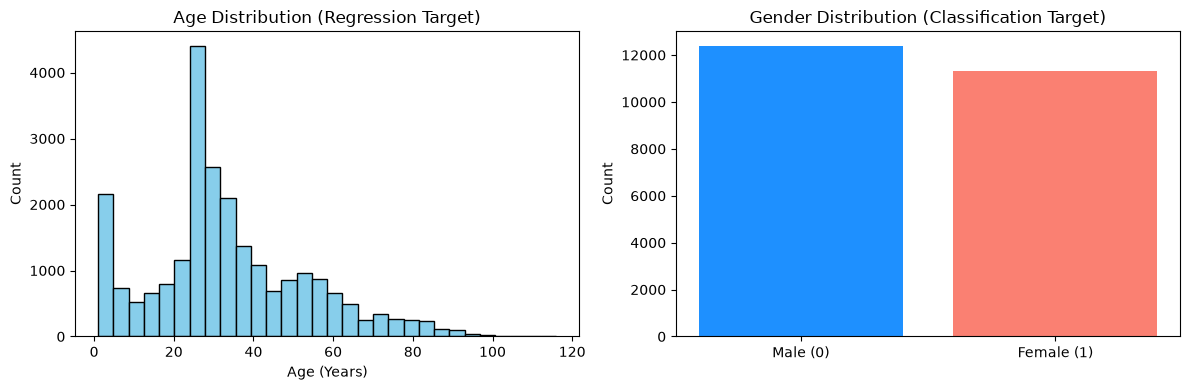

=== 0.2 สรุปสถิติเบื้องต้น ===
อายุเฉลี่ย : 33.3 ปี (ต่ำสุด 1 - สูงสุด 116)
สัดส่วน ชาย (0): 12391 | หญิง (1): 11314


In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1. Age Distribution
axes[0].hist(df['age'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Age Distribution (Regression Target)')
axes[0].set_xlabel('Age (Years)')
axes[0].set_ylabel('Count')

# 2. Gender Distribution
gender_counts = df['gender'].value_counts()
axes[1].bar(['Male (0)', 'Female (1)'], gender_counts.values, color=['dodgerblue', 'salmon'])
axes[1].set_title('Gender Distribution (Classification Target)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print("=== 0.2 สรุปสถิติเบื้องต้น ===")
print(f"อายุเฉลี่ย : {df['age'].mean():.1f} ปี (ต่ำสุด {df['age'].min()} - สูงสุด {df['age'].max()})")
print(f"สัดส่วน ชาย (0): {gender_counts.get(0, 0)} | หญิง (1): {gender_counts.get(1, 0)}")

### 0.3 Feature Extraction with PCA (การลดมิติข้อมูลด้วย PCA)
*   **เป้าหมาย:** ลดความซับซ้อนของข้อมูลภาพจาก 2,304 พิกเซล ให้เหลือ 50 Principal Components (PCs) เพื่อให้ประมวลผลเร็วขึ้น
*   **กระบวนการ:**
    *   สุ่มเลือกข้อมูล (Sample) จำนวน 6,000 ภาพ
    *   ใช้ Principal Component Analysis (PCA) บีบอัดข้อมูลเหลือ 50 มิติ

In [ ]:
### 0.3 Feature Extraction with PCA (การลดมิติข้อมูลด้วย PCA)
*   **เป้าหมาย:** ลดความซับซ้อนของข้อมูลภาพจาก 2,304 พิกเซล ให้เหลือ 50 Principal Components (PCs) เพื่อให้ประมวลผลเร็วขึ้น
*   **กระบวนการ:**
    *   สุ่มเลือกข้อมูล (Sample) จำนวน 6,000 ภาพ
    *   ใช้ Principal Component Analysis (PCA) บีบอัดข้อมูลเหลือ 50 มิติ

In [3]:
from sklearn.decomposition import PCA

SEED = 42
# สุ่มข้อมูลมา 6,000 ภาพเพื่อให้ประมวลผลได้รวดเร็ว
sub = df.sample(6000, random_state=SEED).reset_index(drop=True)

# แปลง pixels ทั้งหมด
X_sub = np.stack(sub['pixels'].apply(decode_pixels)).reshape(len(sub), -1)

# ทำ PCA ลดมิติเหลือ 50 PCs
N_PC = 50
pca = PCA(n_components=N_PC, random_state=SEED)
Z_sub = pca.fit_transform(X_sub)
explained_var = np.sum(pca.explained_variance_ratio_) * 100

print("=== 0.3 การเตรียม Features ด้วย PCA ===")
print(f"มิติเดิม (Raw Pixels) : {X_sub.shape}")
print(f"มิติใหม่หลัง PCA       : {Z_sub.shape}")
print(f"ความแปรปรวนที่อธิบายได้ (Variance Ratio) จาก 50 PCs : {explained_var:.2f}%")

=== 0.3 การเตรียม Features ด้วย PCA ===
มิติเดิม (Raw Pixels) : (6000, 2304)
มิติใหม่หลัง PCA       : (6000, 50)
ความแปรปรวนที่อธิบายได้ (Variance Ratio) จาก 50 PCs : 88.18%


## 🧪 LAB 1: Regression (การทำนายอายุ)

### 1.1 Simple Linear Regression (โมเดลเชิงเส้นตัวแปรเดียว)
*   **เป้าหมาย:** สร้างโมเดลทำนายอายุที่เรียบง่ายที่สุดโดยใช้ Feature 1 ตัวที่มีความสัมพันธ์กับอายุมากที่สุด

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

age_sub = sub['age'].values

# หา PC ที่มี Correlation กับอายุมากที่สุด
age_correlations = [np.corrcoef(Z_sub[:, i], age_sub)[0, 1] for i in range(N_PC)]
BEST_PC_AGE = np.argmax(np.abs(age_correlations))

x_all = Z_sub[:, BEST_PC_AGE].reshape(-1, 1)
y_all = age_sub

# เทรนโมเดล
simple_lr = LinearRegression().fit(x_all, y_all)
r2_simple = r2_score(y_all, simple_lr.predict(x_all))

print("=== 1.1 Simple Linear Regression ===")
print(f"ตัวแปรที่เลือก : PC_{BEST_PC_AGE}")
print(f"R² Score (1 PC) : {r2_simple:.4f}")

=== 1.1 Simple Linear Regression ===
ตัวแปรที่เลือก : PC_19
R² Score (1 PC) : 0.0513


### 1.2 Multiple Linear Regression (โมเดลเชิงเส้นหลายตัวแปร)
*   **เป้าหมาย:** เพิ่มประสิทธิภาพการทำนายอายุโดยใช้ข้อมูลทั้งหมด (50 PCs)
*   **กระบวนการ:** แบ่ง Train/Test 75:25 และเทรนโมเดล

In [5]:
from sklearn.model_selection import train_test_split

# แบ่ง Train 75% / Test 25%
Ztr, Zte, atr, ate = train_test_split(Z_sub, age_sub, test_size=0.25, random_state=SEED)

model_multi = LinearRegression().fit(Ztr, atr)

train_r2 = r2_score(atr, model_multi.predict(Ztr))
test_r2 = r2_score(ate, model_multi.predict(Zte))

print("=== 1.2 Multiple Linear Regression ===")
print(f"Train R² Score (50 PCs) : {train_r2:.4f}")
print(f"Test R² Score (50 PCs)  : {test_r2:.4f}")

=== 1.2 Multiple Linear Regression ===
Train R² Score (50 PCs) : 0.3632
Test R² Score (50 PCs)  : 0.3779


### 1.3 Age Prediction (การประเมินผลการทำนายอายุจริง)
*   **เป้าหมาย:** วัดความคลาดเคลื่อนของโมเดลให้อยู่ในหน่วย "ปี" (MAE และ RMSE)

In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

age_pred = model_multi.predict(Zte)

mae = mean_absolute_error(ate, age_pred)
rmse = np.sqrt(mean_squared_error(ate, age_pred))

print("=== 1.3 Age Prediction ===")
print(f"MAE  (คลาดเคลื่อนเฉลี่ย) : ±{mae:.2f} ปี")
print(f"RMSE (Root Mean Square Error) : {rmse:.2f} ปี")
print("\nตัวอย่างผลการทำนาย:")
for i in range(5):
    print(f"ภาพที่ {i+1}: อายุจริง = {ate[i]} ปี | โมเดลทาย = {age_pred[i]:.1f} ปี")

=== 1.3 Age Prediction ===
MAE  (คลาดเคลื่อนเฉลี่ย) : ±12.26 ปี
RMSE (Root Mean Square Error) : 15.67 ปี

ตัวอย่างผลการทำนาย:
ภาพที่ 1: อายุจริง = 39 ปี | โมเดลทาย = 41.8 ปี
ภาพที่ 2: อายุจริง = 28 ปี | โมเดลทาย = 26.5 ปี
ภาพที่ 3: อายุจริง = 1 ปี | โมเดลทาย = 17.9 ปี
ภาพที่ 4: อายุจริง = 22 ปี | โมเดลทาย = 29.2 ปี
ภาพที่ 5: อายุจริง = 35 ปี | โมเดลทาย = 33.7 ปี


## 🧪 LAB 2: Classification (การทำนายเพศ)

### 2.1 Preparing Classification Data (การเตรียมข้อมูล)
*   **เป้าหมาย:** กรองข้อมูลเฉพาะกลุ่ม "ผู้ใหญ่" ($\ge 18$ ปี) และแบ่ง Train/Test แบบ Stratified Split เพื่อรักษาสัดส่วนเพศ

In [7]:
gender_sub = sub['gender'].values

# กรองเฉพาะ Age >= 18
adult = age_sub >= 18
Z_ad = Z_sub[adult]
g_ad = gender_sub[adult]

# Stratify Split
idx_tr, idx_te = train_test_split(np.arange(len(g_ad)), test_size=0.25, random_state=SEED, stratify=g_ad)

print("=== 2.1 Preparing Classification Data ===")
print(f"จำนวนข้อมูลผู้ใหญ่ทั้งหมด : {len(g_ad)} ภาพ")
print(f"Train Data: {len(idx_tr)} ภาพ | Test Data: {len(idx_te)} ภาพ")
print(f"สัดส่วนเพศหญิงใน Train : {np.mean(g_ad[idx_tr] == 1)*100:.2f}%")

=== 2.1 Preparing Classification Data ===
จำนวนข้อมูลผู้ใหญ่ทั้งหมด : 4965 ภาพ
Train Data: 3723 ภาพ | Test Data: 1242 ภาพ
สัดส่วนเพศหญิงใน Train : 46.87%


### 2.2 Decision Boundary Visualization (การวาดเส้นแบ่งเขตการตัดสินใจ)
*   **เป้าหมาย:** ทำความเข้าใจกลไกการแยกคลาสของ Logistic Regression จากการพล็อต 2 มิติ (ใช้ 2 PCs ที่ดีที่สุด)

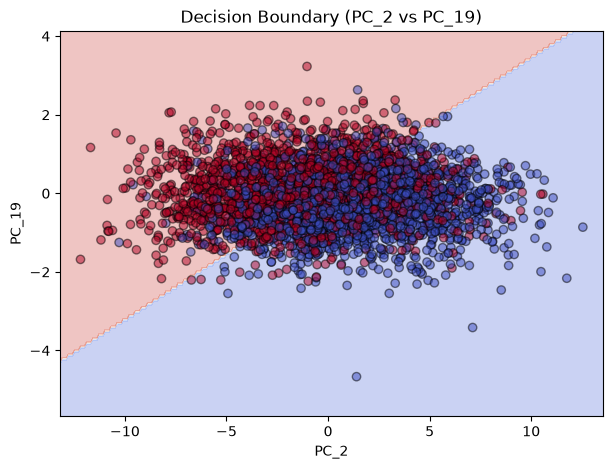

In [8]:
from sklearn.linear_model import LogisticRegression

# หา 2 PCs ที่มี Correlation สูงสุดกับเพศ
corr = [abs(np.corrcoef(Z_ad[:, i], g_ad)[0, 1]) for i in range(N_PC)]
PC_A, PC_B = np.argsort(corr)[-2:][::-1]

Z2_tr = Z_ad[idx_tr][:, [PC_A, PC_B]]
g_tr = g_ad[idx_tr]

clf2 = LogisticRegression().fit(Z2_tr, g_tr)

# Plot Decision Boundary
x_min, x_max = Z2_tr[:, 0].min() - 1, Z2_tr[:, 0].max() + 1
y_min, y_max = Z2_tr[:, 1].min() - 1, Z2_tr[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
Z_grid = clf2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, Z_grid, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(Z2_tr[:, 0], Z2_tr[:, 1], c=g_tr, cmap=plt.cm.coolwarm, edgecolors='k', alpha=0.5)
plt.title(f'Decision Boundary (PC_{PC_A} vs PC_{PC_B})')
plt.xlabel(f'PC_{PC_A}')
plt.ylabel(f'PC_{PC_B}')
plt.show()

### 2.3 Logistic Regression & Probability Output (ความน่าจะเป็นในการทำนาย)
*   **เป้าหมาย:** เข้าใจรูปแบบผลลัพธ์ของ Logistic Regression ที่ออกมาเป็นค่าความน่าจะเป็นผ่านฟังก์ชัน Sigmoid

In [9]:
Z50_tr, Z50_te = Z_ad[idx_tr], Z_ad[idx_te]
g_te = g_ad[idx_te]

clf50 = LogisticRegression(max_iter=2000).fit(Z50_tr, g_tr)
probs = clf50.predict_proba(Z50_te)

print("=== 2.3 Logistic Regression Probability ===")
for i in range(5):
    print(f"ตัวอย่าง {i+1}: P(ชาย)= {probs[i][0]:.3f} | P(หญิง)= {probs[i][1]:.3f} -> ทาย: {'หญิง' if probs[i][1]>=0.5 else 'ชาย'}")

=== 2.3 Logistic Regression Probability ===
ตัวอย่าง 1: P(ชาย)= 0.999 | P(หญิง)= 0.001 -> ทาย: ชาย
ตัวอย่าง 2: P(ชาย)= 0.185 | P(หญิง)= 0.815 -> ทาย: หญิง
ตัวอย่าง 3: P(ชาย)= 0.986 | P(หญิง)= 0.014 -> ทาย: ชาย
ตัวอย่าง 4: P(ชาย)= 0.796 | P(หญิง)= 0.204 -> ทาย: ชาย
ตัวอย่าง 5: P(ชาย)= 0.878 | P(หญิง)= 0.122 -> ทาย: ชาย
